In [1]:
import os
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. 設定資料路徑並讀取上一步清洗好的資料
current_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else os.getcwd()
if os.path.basename(current_dir) == "notebooks":
    base_dir = os.path.dirname(current_dir)
else:
    base_dir = current_dir

data_path = os.path.join(base_dir, "data", "processed", "cleaned_school_safety.csv")

try:
    df_anova = pd.read_csv(data_path)
    
    print("=" * 60)
    print("【雙因子 ANOVA 變數類型檢查】")
    # 統計學要求：ANOVA 的自變數必須被視為「類別型（Categorical/Factor）」
    # 雖然 Grade 是 1~4、Sad_Hopeless 是 0~1，我們要明確指定它們是類別型變數
    df_anova['Grade'] = df_anova['Grade'].astype(str)
    df_anova['Sad_Hopeless'] = df_anova['Sad_Hopeless'].astype(str)
    
    print(df_anova[['Grade', 'Sad_Hopeless', 'Safety_Score']].dtypes)
    print(f"用於分析的樣本總數: {len(df_anova)} 筆")

    print("=" * 60)
    print("【執行雙因子變異數分析 (Two-Way ANOVA)】")
    
    # 2. 設定統計模型公式
    # C() 代表 Categorical 類別變數
    # : 代表計算兩個自變數之間的「交互作用 (Interaction Effect)」
    formula = 'Safety_Score ~ C(Grade) + C(Sad_Hopeless) + C(Grade):C(Sad_Hopeless)'
    
    # 建立線性模型
    model = ols(formula, data=df_anova).fit()
    
    # 3. 產出標準 ANOVA 表 (使用 Type II 或 Type III 變異數平方和，此處採用常規 Type II)
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    # 為了報表美觀，調整欄位名稱
    anova_table.columns = ['平方和 (Sum of Squares)', '自由度 (df)', 'F 檢定值 (F)', '顯著性 (p-value)']
    
    print("\n TWO-WAY ANOVA 分析結果表：")
    print("-" * 70)
    print(anova_table.round(4))  # 四捨五入到小數點後四位
    print("-" * 70)
    
    # 4. 簡單的一鍵基本解讀說明
    print("\n統計顯著性：")
    for index, row in anova_table.iterrows():
        if index != 'Residual':
            p_val = row['顯著性 (p-value)']
            if p_val < 0.05:
                print(f"  - [{index}] 的 p-value = {p_val:.4f} < 0.05  達到顯著差異！")
            else:
                print(f"  - [{index}] 的 p-value = {p_val:.4f} >= 0.05 (未達顯著差異)")

except Exception as e:
    print(f"❌ 執行 ANOVA 時發生錯誤: {e}")

【雙因子 ANOVA 變數類型檢查】
Grade               str
Sad_Hopeless        str
Safety_Score    float64
dtype: object
用於分析的樣本總數: 13360 筆
【執行雙因子變異數分析 (Two-Way ANOVA)】

 TWO-WAY ANOVA 分析結果表：
----------------------------------------------------------------------
                          平方和 (Sum of Squares)  自由度 (df)  F 檢定值 (F)  \
C(Grade)                          5.194051e+03       3.0     4.5642   
C(Sad_Hopeless)                   1.339070e+05       1.0   353.0105   
C(Grade):C(Sad_Hopeless)          9.775231e+02       3.0     0.8590   
Residual                          5.064795e+06   13352.0        NaN   

                          顯著性 (p-value)  
C(Grade)                         0.0034  
C(Sad_Hopeless)                  0.0000  
C(Grade):C(Sad_Hopeless)         0.4616  
Residual                            NaN  
----------------------------------------------------------------------

統計顯著性：
  - [C(Grade)] 的 p-value = 0.0034 < 0.05  達到顯著差異！
  - [C(Sad_Hopeless)] 的 p-value = 0.0000 < 0.05  達到顯著差異！
 

【 1. 交叉分組統計人數與風險分數平均值 】
                       總人數 (N)  平均風險分數
Grade_Label Sad_Label                 
10th        No            2328    9.48
            Yes            994   15.66
11th        No            2385    8.49
            Yes            967   15.46
12th        No            2362    7.87
            Yes           1032   14.66
9th         No            2339    9.09
            Yes            953   16.94
【 2. 進行年級的事後檢定 (Tukey HSD) 】
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   1.0    2.0  -0.0358 0.9999 -1.2826  1.2109  False
   1.0    3.0  -0.8671 0.2777 -2.1111  0.3769  False
   1.0    4.0  -1.4353 0.0156 -2.6754 -0.1952   True
   2.0    3.0  -0.8313 0.3127 -2.0724  0.4098  False
   2.0    4.0  -1.3995 0.0192 -2.6368 -0.1622   True
   3.0    4.0  -0.5682 0.6379 -1.8027  0.6663  False
----------------------------------------------------
【 3. 繪製雙因子 ANOVA 交互作用圖並存入 f

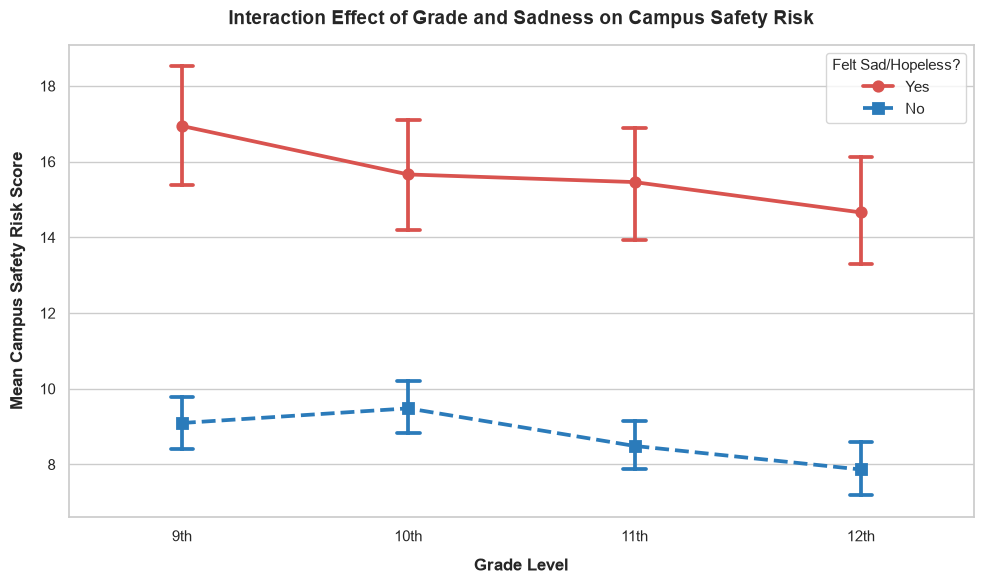


 統計圖表已成功繪出並儲存至: c:\Users\User\Desktop\Project-Final\outputs\figures\anova_interaction_plot.png


In [4]:
current_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else os.getcwd()
if os.path.basename(current_dir) == "notebooks":
    base_dir = os.path.dirname(current_dir)
else:
    base_dir = current_dir

data_path = os.path.join(base_dir, "data", "processed", "cleaned_school_safety.csv")
figures_dir = os.path.join(base_dir, "outputs", "figures")
os.makedirs(figures_dir, exist_ok=True) # 自動建立 reports/figures/ 資料夾

# 讀取清洗後的資料
df_analysis = pd.read_csv(data_path)

print("=" * 60)
print("【 1. 交叉分組統計人數與風險分數平均值 】")
# 同時計算人數 (count) 與平均值 (mean)
# 將年級 1~4 對應為 9~12 年級，悲傷 0~1 對應為 No/Yes 方便閱讀
df_stats = df_analysis.copy()
df_stats['Grade_Label'] = df_stats['Grade'].map({1: '9th', 2: '10th', 3: '11th', 4: '12th'})
df_stats['Sad_Label'] = df_stats['Sad_Hopeless'].map({0: 'No', 1: 'Yes'})

summary_table = df_stats.groupby(['Grade_Label', 'Sad_Label'])['Safety_Score'].agg(['count', 'mean']).round(2)
summary_table.columns = ['總人數 (N)', '平均風險分數']
print(summary_table)

print("=" * 60)
print("【 2. 進行年級的事後檢定 (Tukey HSD) 】")
tukey = pairwise_tukeyhsd(endog=df_analysis['Safety_Score'],
                          groups=df_analysis['Grade'].astype(str),
                          alpha=0.05)
print(tukey)

print("=" * 60)
print("【 3. 繪製雙因子 ANOVA 交互作用圖並存入 figures 】")

# 設定圖表美化樣式
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 使用 seaborn 畫出折線圖（帶有信心區間的誤差棒，非常專業）
# x軸為年級，y軸為安全風險總分，hue(顏色分組)為是否悲傷
ax = sns.pointplot(
    data=df_stats, 
    x='Grade_Label', 
    y='Safety_Score', 
    hue='Sad_Label',
    order=['9th', '10th', '11th', '12th'],
    palette={'No': '#2b7bba', 'Yes': '#d9534f'}, # 藍色代表正常，紅色代表悲傷高風險
    markers=["o", "s"], 
    linestyles=["-", "--"],
    errorbar='ci', # 顯示 95% 信心區間
    capsize=0.1
)

# 加強圖表標題與標籤
plt.title('Interaction Effect of Grade and Sadness on Campus Safety Risk', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Grade Level', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Mean Campus Safety Risk Score', fontsize=12, fontweight='bold', labelpad=10)
plt.legend(title='Felt Sad/Hopeless?', title_fontsize='11', loc='upper right')

plt.tight_layout()

# 🎯 自動儲存至 reports/figures/ 資料夾
output_fig_path = os.path.join(figures_dir, "anova_interaction_plot.png")
plt.savefig(output_fig_path, dpi=300) # 300 dpi 確保高畫質印刷/簡報清晰度
plt.show()

print(f"\n 統計圖表已成功繪出並儲存至: {output_fig_path}")

In [3]:
import os
import pandas as pd

# 1. 設定資料路徑並讀取
current_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else os.getcwd()
if os.path.basename(current_dir) == "notebooks":
    base_dir = os.path.dirname(current_dir)
else:
    base_dir = current_dir

data_path = os.path.join(base_dir, "data", "processed", "cleaned_school_safety.csv")

try:
    df_safety = pd.read_csv(data_path)
    
    # 2. 篩選出 Risk_Level 為 'High' 的學生
    df_high_risk = df_safety[df_safety['Risk_Level'] == 'High'].copy()
    
    total_high_risk = len(df_high_risk)
    print("=" * 60)
    print(f" 【高風險群體分析報告】 ")
    print(f"在全體有效樣本中，被評為「高風險 (High)」的學生總人數為: {total_high_risk} 人")
    print("=" * 60)
    
    if total_high_risk == 0:
        print("目前分類中沒有高風險學生，請檢查先前的評分級距設定。")
    else:
        # 為了報表好看，建立標籤對應
        df_high_risk['Grade_Label'] = df_high_risk['Grade'].map({1: '9th Grade', 2: '10th Grade', 3: '11th Grade', 4: '12th Grade'})
        df_high_risk['Sad_Label'] = df_high_risk['Sad_Hopeless'].map({0: 'No (未感到悲傷)', 1: 'Yes (感到悲傷絕望)'})
        
        # 3. 統計年級人數分佈
        print("\n 1. 高風險群體中【各年級】的人數與佔比：")
        grade_counts = df_high_risk['Grade_Label'].value_counts().reindex(['9th Grade', '10th Grade', '11th Grade', '12th Grade'])
        for grade, count in grade_counts.items():
            percentage = (count / total_high_risk) * 100
            print(f"  - {grade}: {count:4d} 人 ({percentage:.2f}%)")
            
        print("-" * 50)
        
        # 4. 統計是否感到悲傷人數分佈
        print("\n 2. 高風險群體中【心理健康（是否悲傷）】的人數與佔比：")
        sad_counts = df_high_risk['Sad_Label'].value_counts()
        for sad_status, count in sad_counts.items():
            percentage = (count / total_high_risk) * 100
            print(f"  - {sad_status}: {count:4d} 人 ({percentage:.2f}%)")
            
        print("=" * 60)
        
        # 5. 額外加碼：將高風險學生的名單單獨匯出（供未來研究或輔導室追蹤使用）
        high_risk_output_path = os.path.join(base_dir, "data", "processed", "high_risk_students.csv")
        df_high_risk.to_csv(high_risk_output_path, index=False)
        print(f"高風險學生的詳細清單已單獨匯出至:\n   {high_risk_output_path}")

except Exception as e:
    print(f"❌ 執行篩選時發生錯誤: {e}")

 【高風險群體分析報告】 
在全體有效樣本中，被評為「高風險 (High)」的學生總人數為: 527 人

 1. 高風險群體中【各年級】的人數與佔比：
  - 9th Grade:  149 人 (28.27%)
  - 10th Grade:  138 人 (26.19%)
  - 11th Grade:  114 人 (21.63%)
  - 12th Grade:  126 人 (23.91%)
--------------------------------------------------

 2. 高風險群體中【心理健康（是否悲傷）】的人數與佔比：
  - No (未感到悲傷):  267 人 (50.66%)
  - Yes (感到悲傷絕望):  260 人 (49.34%)
高風險學生的詳細清單已單獨匯出至:
   c:\Users\User\Desktop\Project-Final\data\processed\high_risk_students.csv


In [ ]:
import os
import pandas as pd

# 1. 設定路徑並讀取高風險學生資料
current_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else os.getcwd()
if os.path.basename(current_dir) == "notebooks":
    base_dir = os.path.dirname(current_dir)
else:
    base_dir = current_dir

high_risk_path = os.path.join(base_dir, "data", "processed", "high_risk_students.csv")

try:
    df_high = pd.read_csv(high_risk_path)
    
    print("=" * 70)
    print(f" 【高風險群體全變數自動掃描 - 鎖定『有發生行為』之最大特徵】 (總人數: {len(df_high)} 人)")
    print("=" * 70)
    
    features_summary = []
    
    # 排除掉我們後來自己加工的模型變數
    columns_to_scan = [col for col in df_high.columns if col not in ['Safety_Score', 'Risk_Level', 'Grade_Label', 'Sad_Label', 'Grade']]
    
    # 2. 開始自動掃描 103 個變數
    for col in columns_to_scan:
        
        valid_responses = df_high[col].dropna()
        if len(valid_responses) == 0:
            continue
            
        #  核心防呆修正邏輯：根據變數類型，排除代表「沒有發生」的選項，只統計「有發生」的選項
        if col == 'Sad_Hopeless':
            # 根據評分對應，0 代表沒有感到悲傷，1 代表有感到悲傷
            has_behavior_responses = valid_responses[valid_responses == 1]
        elif col == 'Drug_School':
            # 根據評分對應，1 代表 Yes (有遇到毒品)，2 代表 No (沒有)
            has_behavior_responses = valid_responses[valid_responses == 1]
        else:
            # 一般次數/天數題：選項 1 代表沒有發生（0次/0天），大於 1 才是有發生
            has_behavior_responses = valid_responses[valid_responses > 1]
            
        # 如果這群高風險學生在這一題「完全沒有人發生過該行為」，就跳過不列入危險特徵
        if len(has_behavior_responses) == 0:
            continue
            
        # 計算在【有發生行為的群體】中，各選項的人數與比例
        value_counts = has_behavior_responses.value_counts()
        
        top_option = value_counts.idxmax()       # 排除"沒有"之後，最常發生的具體選項次數/天數
        top_count = value_counts.max()           # 選該危險選項的實際人數
        valid_total = len(valid_responses)       # 這一題「有填答」的總人數（分母保持全體有效填答，確保百分比客觀）
        top_pct = (top_count / valid_total) * 100 # 算出該極端行為在全體高風險學生中的精確佔比
        
        features_summary.append({
            '原始變數名稱': col,
            '最多人選的有發生選項': int(top_option) if isinstance(top_option, (int, float)) else top_option,
            '高風險中該項填答人數': top_count,
            '該題有效總填答人數': valid_total,
            '有效佔比 (%)': round(top_pct, 2)
        })
            
    # 3. 轉換成 DataFrame 並依照「有效佔比」從高到低排序
    df_features = pd.DataFrame(features_summary)
    df_features_sorted = df_features.sort_values(by='有效佔比 (%)', ascending=False)
    
    # 4. 輸出前 20 名最集中的高風險特徵
    print(" 高風險學生特徵最集中的前 20 個特徵（已自動剔除『未發生(1)』選項）：")
    print("-" * 80)
    print(df_features_sorted.head(20).to_string(index=False))
    print("-" * 80)
    print(" 該特定『有發生的危險行為選項』佔高風險群體的百分比。")
    print("=" * 70)
    
except Exception as e:
    print(f"❌ 掃描原始變數時發生錯誤: {e}")

 【高風險群體全變數自動掃描 - 鎖定『有發生行為』之最大特徵】 (總人數: 527 人)
 高風險學生特徵最集中的前 20 個特徵（已自動剔除『未發生(1)』選項）：
--------------------------------------------------------------------------------
       原始變數名稱  最多人選的有發生選項  高風險中該項填答人數  該題有效總填答人數  有效佔比 (%)
  Drug_School           1         382        527     72.49
Weapon_School           5         275        527     52.18
 Sad_Hopeless           1         260        527     49.34
  Fight_Total           3         132        527     25.05
 Fight_School           2         100        527     18.98
Injected_Drug           3          64        527     12.14
--------------------------------------------------------------------------------
 該特定『有發生的危險行為選項』佔高風險群體的百分比。


🔥 自動篩選：高低風險群體中『實際行為特徵差距最大』的前 6 個指標：
     Variable  Top_Option  High_Risk_Pct  Non_High_Risk_Pct   Gap
  Drug_School           1          72.49              20.46 52.03
Weapon_School           5          52.18               0.58 51.60
 Sad_Hopeless           1          49.34              28.72 20.61
  Fight_Total           3          25.05              11.29 13.76
Injected_Drug           3          12.14               0.43 11.72
 Fight_School           2          18.98               7.80 11.18


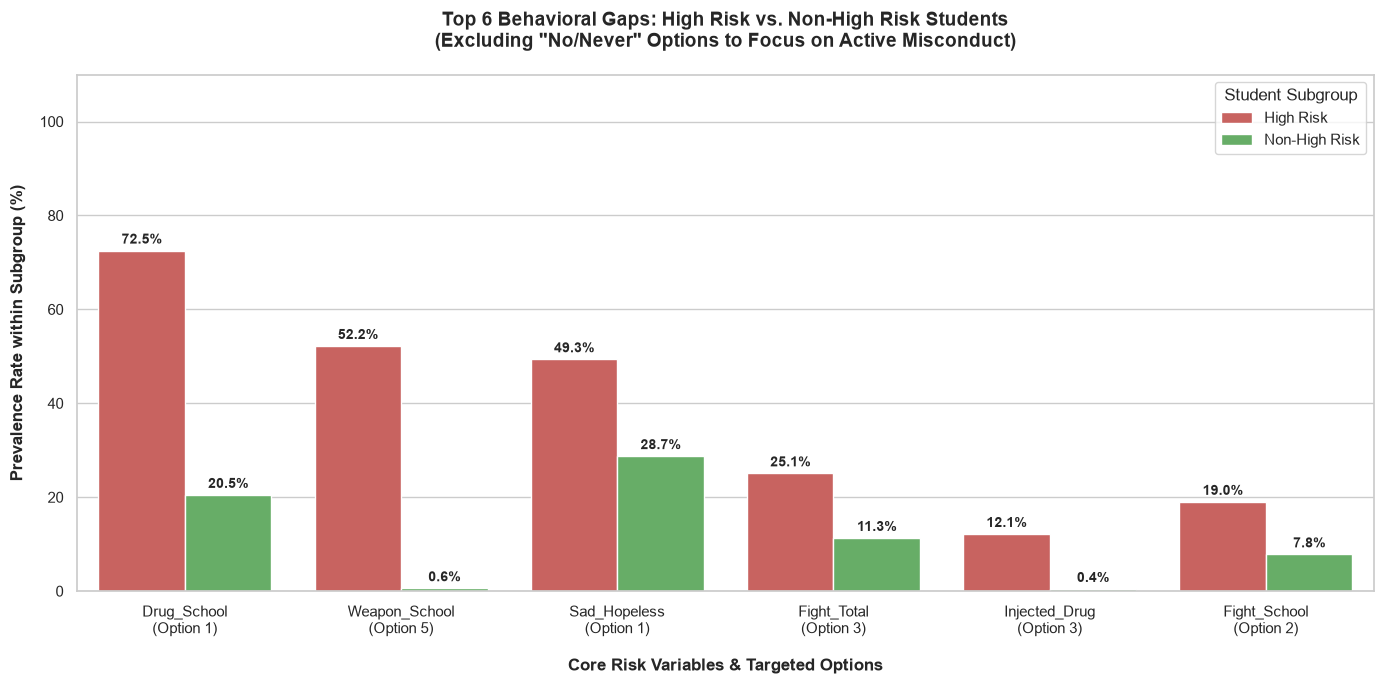

🎉 完美的雙群體行為特徵對比圖已成功輸出至: c:\Users\User\Desktop\Project-Final\outputs\figures\top_behavioral_gaps_comparison.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 設定路徑（對齊你的專案目錄結構）
current_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else os.getcwd()
base_dir = os.path.dirname(current_dir) if os.path.basename(current_dir) == "notebooks" else current_dir

data_path = os.path.join(base_dir, "data", "processed", "cleaned_school_safety.csv")
figures_dir = os.path.join(base_dir, "outputs", "figures")
os.makedirs(figures_dir, exist_ok=True)

try:
    df_safety = pd.read_csv(data_path)
    
    # 定義對比群體
    df_safety['Group_Type'] = df_safety['Risk_Level'].apply(lambda x: 'High Risk' if x == 'High' else 'Non-High Risk')
    
    # 排除加工過的模型欄位
    columns_to_scan = [col for col in df_safety.columns if col not in ['Safety_Score', 'Risk_Level', 'Grade_Label', 'Sad_Label', 'Group_Type', 'Grade']]
    
    features_gap_analysis = []
    
    # 2. 自動掃描 103 個變數，精準找出「有發生行為」的最高佔比選項與群體差距
    for col in columns_to_scan:
        valid_high = df_safety[df_safety['Group_Type'] == 'High Risk'][col].dropna()
        valid_non_high = df_safety[df_safety['Group_Type'] == 'Non-High Risk'][col].dropna()
        
        if len(valid_high) == 0 or len(valid_non_high) == 0:
            continue
            
        # 🌟 對齊你的真實 Codebook 機制：排除代表「未發生」的選項
        if col == 'Sad_Hopeless':
            behavior_condition = 1  # 1 = 有感到悲傷
            high_behavior = valid_high[valid_high == behavior_condition]
        elif col == 'Drug_School':
            behavior_condition = 1  # 1 = 有遇到校園毒品交易
            high_behavior = valid_high[valid_high == behavior_condition]
        else:
            # 一般次數題：> 1 代表有發生
            high_behavior = valid_high[valid_high > 1]
            
        if len(high_behavior) == 0:
            continue
            
        # 🎯 找出高風險組中「哪一個有發生的選項」最多人選 (大魔王選項)
        top_behavior_option = high_behavior.value_counts().idxmax()
        
        # 計算兩組人在這個「大魔王選項」上的有效填答佔比 (分母維持該題各自的總有效填答)
        high_pct = (valid_high[valid_high == top_behavior_option].count() / len(valid_high)) * 100
        non_high_pct = (valid_non_high[valid_non_high == top_behavior_option].count() / len(valid_non_high)) * 100
        gap = high_pct - non_high_pct
        
        features_gap_analysis.append({
            'Variable': col,
            'Top_Option': int(top_behavior_option) if isinstance(top_behavior_option, (int, float)) else top_behavior_option,
            'High_Risk_Pct': round(high_pct, 2),
            'Non_High_Risk_Pct': round(non_high_pct, 2),
            'Gap': round(gap, 2)
        })
        
    # 3. 轉為 DataFrame 並依據「兩組差距 (Gap)」由大到小排序，挑出前 6 名
    df_gap = pd.DataFrame(features_comparison_data if 'features_comparison_data' in locals() else features_gap_analysis)
    df_gap_sorted = df_gap.sort_values(by='Gap', ascending=False)
    top_6_features = df_gap_sorted.head(6)
    
    print("=" * 80)
    print("🔥 自動篩選：高低風險群體中『實際行為特徵差距最大』的前 6 個指標：")
    print(top_6_features.to_string(index=False))
    print("=" * 80)
    
    # 4. 將 Top 6 資料轉化為長表格 (Long Format) 以利 Seaborn 繪圖
    plot_data = []
    for _, row in top_6_features.iterrows():
        # 為橫軸建立易讀的標籤組合：變數代號 + 核心選項
        x_label = f"{row['Variable']}\n(Option {row['Top_Option']})"
        plot_data.append({'Behavior_Indicator': x_label, 'Group': 'High Risk', 'Percentage (%)': row['High_Risk_Pct']})
        plot_data.append({'Behavior_Indicator': x_label, 'Group': 'Non-High Risk', 'Percentage (%)': row['Non_High_Risk_Pct']})
    df_plot = pd.DataFrame(plot_data)
    
    # 5. 開始繪製紅綠對比長條圖
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 7))
    
    ax = sns.barplot(
        data=df_plot,
        x='Behavior_Indicator',
        y='Percentage (%)',
        hue='Group',
        palette={'High Risk': '#d9534f', 'Non-High Risk': '#5cb85c'} # 紅色高危，綠色非高危
    )
    
    # 在長條圖上方自動標記百分比數值
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        fontsize=10, fontweight='bold', xytext=(0, 3),
                        textcoords='offset points')
            
    plt.title('Top 6 Behavioral Gaps: High Risk vs. Non-High Risk Students\n(Excluding "No/Never" Options to Focus on Active Misconduct)', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Core Risk Variables & Targeted Options', fontsize=12, fontweight='bold', labelpad=15)
    plt.ylabel('Prevalence Rate within Subgroup (%)', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylim(0, 110)
    plt.legend(title='Student Subgroup', loc='upper right')
    
    plt.tight_layout()
    
    # 6. 存入 outputs/figures
    output_fig_path = os.path.join(figures_dir, "top_behavioral_gaps_comparison.png")
    plt.savefig(output_fig_path, dpi=300)
    plt.show()
    
    print(f"🎉 完美的雙群體行為特徵對比圖已成功輸出至: {output_fig_path}")

except Exception as e:
    print(f"❌ 執行特徵比對繪圖時發生錯誤: {e}")

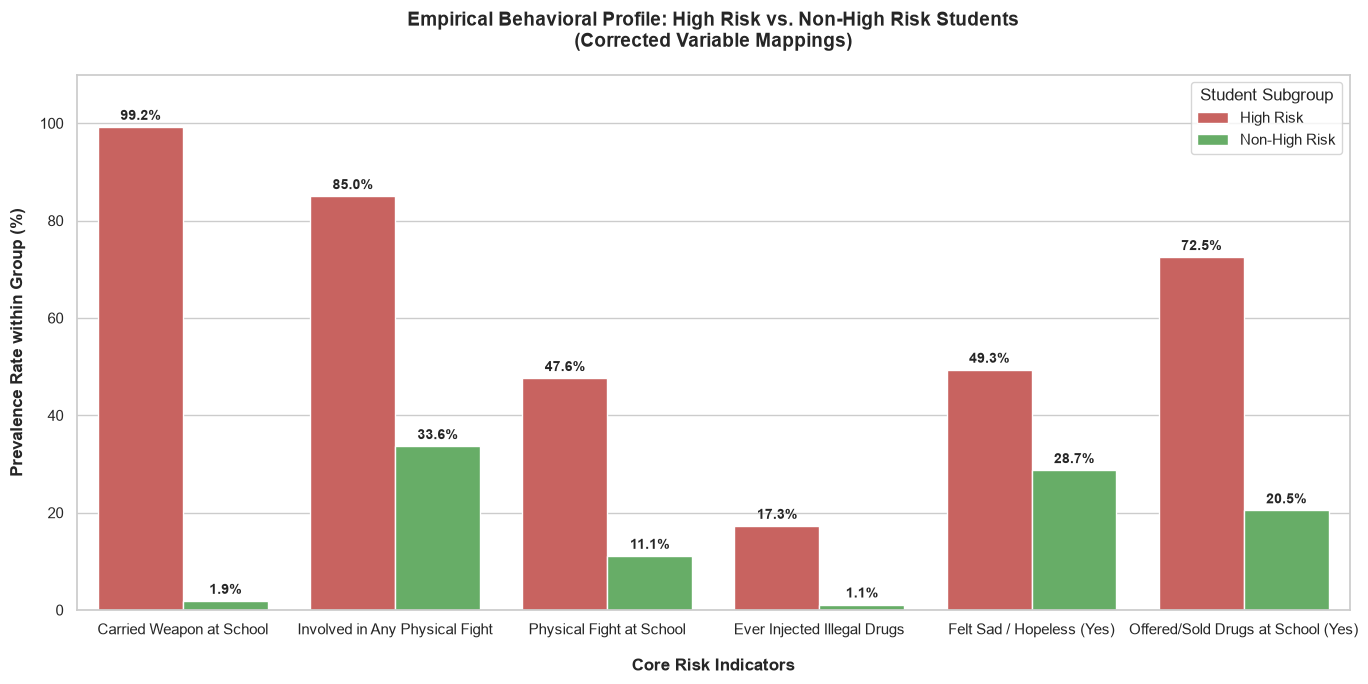

🎉 乾淨、精準、完全修正的對比圖表已成功存入: c:\Users\User\Desktop\Project-Final\outputs\figures\final_corrected_profile_comparison.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 設定路徑
current_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else os.getcwd()
base_dir = os.path.dirname(current_dir) if os.path.basename(current_dir) == "notebooks" else current_dir

data_path = os.path.join(base_dir, "data", "processed", "cleaned_school_safety.csv")
figures_dir = os.path.join(base_dir, "outputs", "figures")
os.makedirs(figures_dir, exist_ok=True)

try:
    df_safety = pd.read_csv(data_path)
    df_safety['Group_Type'] = df_safety['Risk_Level'].apply(lambda x: 'High Risk' if x == 'High' else 'Non-High Risk')
    
    # 定義你要對比的 6 大核心指標
    core_columns = ['Weapon_School', 'Fight_Total', 'Fight_School', 'Injected_Drug', 'Sad_Hopeless', 'Drug_School']
    
    plot_data = []
    
    # 2. 精準對齊你的變數對應表
    for col in core_columns:
        for g_type in ['High Risk', 'Non-High Risk']:
            valid_responses = df_safety[df_safety['Group_Type'] == g_type][col].dropna()
            
            if len(valid_responses) == 0:
                continue
                
            # 🌟 根據你的真實 codebook 對齊條件
            if col == 'Sad_Hopeless':
                has_behavior = (valid_responses == 1).sum()  # 1 = Yes (感到悲傷)
            elif col == 'Drug_School':
                has_behavior = (valid_responses == 1).sum()  # 1 = Yes (在校遇到毒品)
            else:
                has_behavior = (valid_responses > 1).sum()   # 其他題目 > 1 代表有發生
                
            pct = (has_behavior / len(valid_responses)) * 100
            
            # 轉換易讀標籤用於圖表橫軸
            label_map = {
                'Weapon_School': 'Carried Weapon at School',
                'Fight_Total': 'Involved in Any Physical Fight',
                'Fight_School': 'Physical Fight at School',
                'Injected_Drug': 'Ever Injected Illegal Drugs',
                'Sad_Hopeless': 'Felt Sad / Hopeless (Yes)',
                'Drug_School': 'Offered/Sold Drugs at School (Yes)'
            }
            
            plot_data.append({
                'Behavior': label_map[col],
                'Group': g_type,
                'Percentage (%)': round(pct, 2)
            })
            
    df_plot = pd.DataFrame(plot_data)
    
    # 3. 重新繪製紅綠對比圖
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 7))
    
    ax = sns.barplot(
        data=df_plot,
        x='Behavior',
        y='Percentage (%)',
        hue='Group',
        palette={'High Risk': '#d9534f', 'Non-High Risk': '#5cb85c'}
    )
    
    # 加上數值標籤
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        fontsize=10, fontweight='bold', xytext=(0, 3),
                        textcoords='offset points')
            
    plt.title('Empirical Behavioral Profile: High Risk vs. Non-High Risk Students\n(Corrected Variable Mappings)', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Core Risk Indicators', fontsize=12, fontweight='bold', labelpad=15)
    plt.ylabel('Prevalence Rate within Group (%)', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylim(0, 110)
    plt.legend(title='Student Subgroup', loc='upper right')
    
    plt.tight_layout()
    output_fig_path = os.path.join(figures_dir, "final_corrected_profile_comparison.png")
    plt.savefig(output_fig_path, dpi=300)
    plt.show()
    
    print(f"🎉 乾淨、精準、完全修正的對比圖表已成功存入: {output_fig_path}")

except Exception as e:
    print(f"❌ 繪製終極修正圖表時發生錯誤: {e}")

In [ ]:

# 1. 設定路徑
current_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else os.getcwd()
base_dir = os.path.dirname(current_dir) if os.path.basename(current_dir) == "notebooks" else current_dir

data_path = os.path.join(base_dir, "data", "processed", "cleaned_school_safety.csv")
figures_dir = os.path.join(base_dir, "outputs", "figures")
os.makedirs(figures_dir, exist_ok=True)

try:
    df_safety = pd.read_csv(data_path)
    df_safety['Group_Type'] = df_safety['Risk_Level'].apply(lambda x: 'High Risk' if x == 'High' else 'Non-High Risk')
    
    # 定義你要對比的 6 大核心指標
    core_columns = ['Weapon_School', 'Fight_Total', 'Fight_School', 'Injected_Drug', 'Sad_Hopeless', 'Drug_School']
    
    plot_data = []
    
    # 2. 精準對齊你的變數對應表
    for col in core_columns:
        for g_type in ['High Risk', 'Non-High Risk']:
            valid_responses = df_safety[df_safety['Group_Type'] == g_type][col].dropna()
            
            if len(valid_responses) == 0:
                continue
                
            # 🌟 根據你的真實 codebook 對齊條件
            if col == 'Sad_Hopeless':
                has_behavior = (valid_responses == 1).sum()  # 1 = Yes (感到悲傷)
            elif col == 'Drug_School':
                has_behavior = (valid_responses == 1).sum()  # 1 = Yes (在校遇到毒品)
            else:
                has_behavior = (valid_responses > 1).sum()   # 其他題目 > 1 代表有發生
                
            pct = (has_behavior / len(valid_responses)) * 100
            
            # 轉換易讀標籤用於圖表橫軸
            label_map = {
                'Weapon_School': 'Carried Weapon at School',
                'Fight_Total': 'Involved in Any Physical Fight',
                'Fight_School': 'Physical Fight at School',
                'Injected_Drug': 'Ever Injected Illegal Drugs',
                'Sad_Hopeless': 'Felt Sad / Hopeless (Yes)',
                'Drug_School': 'Offered/Sold Drugs at School (Yes)'
            }
            
            plot_data.append({
                'Behavior': label_map[col],
                'Group': g_type,
                'Percentage (%)': round(pct, 2)
            })
            
    df_plot = pd.DataFrame(plot_data)
    
    # 3. 重新繪製紅綠對比圖
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 7))
    
    ax = sns.barplot(
        data=df_plot,
        x='Behavior',
        y='Percentage (%)',
        hue='Group',
        palette={'High Risk': '#d9534f', 'Non-High Risk': '#5cb85c'}
    )
    
    # 加上數值標籤
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        fontsize=10, fontweight='bold', xytext=(0, 3),
                        textcoords='offset points')
            
    plt.title('Empirical Behavioral Profile: High Risk vs. Non-High Risk Students\n(Corrected Variable Mappings)', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Core Risk Indicators', fontsize=12, fontweight='bold', labelpad=15)
    plt.ylabel('Prevalence Rate within Group (%)', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylim(0, 110)
    plt.legend(title='Student Subgroup', loc='upper right')
    
    plt.tight_layout()
    output_fig_path = os.path.join(figures_dir, "final_corrected_profile_comparison.png")
    plt.savefig(output_fig_path, dpi=300)
    plt.show()
    
    print(f"🎉 乾淨、精準、完全修正的對比圖表已成功存入: {output_fig_path}")

except Exception as e:
    print(f"❌ 繪製終極修正圖表時發生錯誤: {e}")